# Import Libs

In [ ]:
import os
os.environ['HF_HOME'] = '/workspace/huggingface'
import math
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import gc

# Prepare Model n Processors

In [2]:
MIN_PIXELS = 256*256
MAX_PIXELS = 1024*1024

DEVICE = "cuda:0"
TORCH_DTYPE = torch.bfloat16
MODEL_PATH = "Qwen/Qwen2.5-VL-7B-Instruct"

In [3]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=TORCH_DTYPE,
    attn_implementation="eager",
    device_map=DEVICE,
    low_cpu_mem_usage=True,
).eval()
processor = AutoProcessor.from_pretrained(
    MODEL_PATH, 
    trust_remote_code=True, 
    padding_side='left', 
    use_fast=True, 
    min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS
)

Loading checkpoint shards: 100%|██████████| 5/5 [00:30<00:00,  6.03s/it]
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


# Prepare Data to be Run

In [ ]:
from PIL import Image
from qwen_vl_utils import process_vision_info
import

DIAGNOSTIC_DIR= "../../data/diagnostic"
DIAGNOSTIC_CASE = "mock_circles"

with open(os.path.join(DIAGNOSTIC_DIR, 'json', f'{DIAGNOSTIC_CASE}.json'), 'r') as f:
    data = json.load(f)


sample_case = data[2]
img_path = os.path.join(DIAGNOSTIC_DIR, 'img', sample_case['image_path'])
question = sample_case['question']
answer = sample_case.get('answer', sample_case.get('label', ''))

In [ ]:
import json

with open('system_prompt.json', 'r') as f:
    system_prompt = json.load(f)

'''
default, preference, exclusive, empty, negation, long
'''

SYSTEM_PROMPT_TYPE = "preference"
MODALITY_PREFERENCE = "image"
SYSTEM_PROMPT = system_prompt[SYSTEM_PROMPT_TYPE] if type(system_prompt[SYSTEM_PROMPT_TYPE]) == str else system_prompt[SYSTEM_PROMPT_TYPE][MODALITY_PREFERENCE]
IMPORTANT_PROMPT = ""

question = (IMPORTANT_PROMPT + " ") if IMPORTANT_PROMPT else "" + question
messages_query = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img_path},
            {"type": "text", "text": question},
        ],
    }
]

In [ ]:
image_inputs, _ = process_vision_info(messages_query)
text_query = processor.apply_chat_template(messages_query, tokenize=False, add_generation_prompt=False)

# remvoe <im_start> and <im_end> and system from text_query
text_query = text_query \
                .replace('system\n', '') if SYSTEM_PROMPT_TYPE == "empty" else text_query 

print(text_query)

<|im_start|>system
Please focus on image more than text.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>How many circles are there in the image?<|im_end|>



# Feed Inputs to the processor

In [ ]:
def attention_compute(attention, sys_len, img_len):
    attention = torch.mean(attention, dim=1)
    attention = attention.squeeze(0).numpy()

    print(attention.shape)
    
    props_sys = attention[-1][:sys_len].sum()
    props_img = attention[-1][sys_len:sys_len+img_len].sum()
    props_txt = attention[-1][sys_len+img_len:].sum()
    return [props_sys, props_img, props_txt]

def attention_compute_by_idxs(attention, sys_idxs, img_idxs, txt_idxs, special_idxs):
    attention = torch.mean(attention, dim=1)
    attention = attention.squeeze(0).numpy()

    sum_sys = attention[-1][sys_idxs].sum()
    sum_img = attention[-1][img_idxs].sum()
    sum_txt = attention[-1][txt_idxs].sum()
    sum_special = attention[-1][special_idxs].sum()
    
    return [sum_special, sum_sys, sum_img, sum_txt]

In [ ]:
from tqdm import tqdm

inputs = processor(
    text=[text_query],
    images=image_inputs,
    padding=True,
    return_tensors="pt",
).to(DEVICE)

'''
=========SYSTEM PROMPT=========
<|im_start|> 
system
You are a helpful assistant.
<|im_end|>

<|im_start|>user

=========IMAGE PROMPT=========
<|vision_start|><|image_pad|><|vision_end|>

=========USER PROMPT=========
How many headsets are there in the image?

<|im_end|>
'''

# Extract input token IDs
input_ids = inputs['input_ids'][0].tolist()

# Get special token IDs
im_start_token_id = processor.tokenizer.convert_tokens_to_ids('<|im_start|>')
im_end_token_id = processor.tokenizer.convert_tokens_to_ids('<|im_end|>')
vision_start_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_start|>')
vision_end_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_end|>')
image_pad_token_id = processor.tokenizer.convert_tokens_to_ids('<|image_pad|>')

# Find key positions in the token sequence
first_im_start_pos = input_ids.index(im_start_token_id)
first_im_end_pos = input_ids.index(im_end_token_id)
second_im_start_pos = input_ids.index(im_start_token_id, first_im_end_pos + 1)
second_im_end_pos = input_ids.index(im_end_token_id, second_im_start_pos + 1)

# Initialize index arrays for different token categories
special_token_indices = []
system_indices = []
image_indices = []
text_indices = []

# Categorize tokens according to the simplified rules
for i, token_id in enumerate(input_ids):
    token = processor.tokenizer.convert_ids_to_tokens([token_id])[0]
    
    # Special tokens: any token with <| |> style, except <|image_pad|>
    if token.startswith('<|') and token.endswith('|>') and token != '<|image_pad|>':
        special_token_indices.append(i)
    
    # Vision tokens: all <|image_pad|> tokens
    elif token_id == image_pad_token_id:
        image_indices.append(i)
    
    # System tokens: all tokens between first <|im_start|> and first <|im_end|>
    elif first_im_start_pos < i < first_im_end_pos:
        system_indices.append(i)
    
    # Text tokens: tokens between second <|im_start|> and <|im_end|> 
    # that are not <|vision_start|> or <|image_pad|>
    elif (second_im_start_pos < i < second_im_end_pos and 
          token_id not in [vision_start_token_id, image_pad_token_id]):
        text_indices.append(i)

system_len = len(system_indices)
img_len = len(image_indices)
system_tokens = [input_ids[i] for i in system_indices]
vision_tokens = [input_ids[i] for i in image_indices]
text_tokens = [input_ids[i] for i in text_indices]

system_text = processor.tokenizer.decode(system_tokens, skip_special_tokens=False)
vision_text = processor.tokenizer.decode(vision_tokens, skip_special_tokens=False)
text_text = processor.tokenizer.decode(text_tokens, skip_special_tokens=False)
special_tokens = [input_ids[i] for i in special_token_indices]
special_text = processor.tokenizer.decode(special_tokens, skip_special_tokens=False)

print(f"System indices: {len(system_indices)}, Image indices: {len(image_indices)}")
print(f"Text indices: {len(text_indices)}, Special token indices: {len(special_token_indices)}")
print(f"System tokens: {len(system_tokens)}, Vision tokens: {len(vision_tokens)}, Text tokens: {len(text_tokens)}, Special tokens: {len(special_token_indices)}")

# labels = inputs['input_ids'].clone()
# labels[:, :vis_end_pos + 1] = -100
# labels[labels == processor.tokenizer.pad_token_id] = -100
results = []
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        output_attentions=True,
        return_dict_in_generate=True,
        temperature=0.0,
    )
    
    # Extract only the newly generated tokens (excluding the input prompt)
    input_length = len(inputs['input_ids'][0])
    generated_ids = outputs.sequences[0][input_length:]
    decoded_output = processor.tokenizer.decode(generated_ids, skip_special_tokens=True)
    print(f"Generated output: {decoded_output}")
    
    layers_attn = []
    for attn in tqdm(outputs.attentions[-1], total = len(outputs.attentions[-1])):
        attn_score = attn.to(torch.float32).cpu()
        attn_props = attention_compute_by_idxs(attn_score, system_indices, image_indices, text_indices, special_token_indices)
        print(attn_props)
        layers_attn.append(attn_props)
        del attn_score, attn_props

    results.append(layers_attn)
    
    del outputs, inputs
    torch.cuda.empty_cache()
    gc.collect()

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


System indices: 10, Image indices: 1295
Text indices: 11, Special token indices: 6
System tokens: 10, Vision tokens: 1295, Text tokens: 11, Special tokens: 6
Generated output:  addCriterion
The image contains a total of eight circles.


100%|██████████| 28/28 [00:00<00:00, 4048.00it/s]

[np.float32(0.07575433), np.float32(0.06348357), np.float32(0.06520629), np.float32(0.20627107)]
[np.float32(0.09060443), np.float32(0.052425165), np.float32(0.02568416), np.float32(0.19076496)]
[np.float32(0.058150634), np.float32(0.1996291), np.float32(0.058569532), np.float32(0.20870647)]
[np.float32(0.032101445), np.float32(0.06813979), np.float32(0.032480564), np.float32(0.20008743)]
[np.float32(0.017283535), np.float32(0.7014346), np.float32(0.015699115), np.float32(0.049801186)]
[np.float32(0.045942213), np.float32(0.67030686), np.float32(0.015497464), np.float32(0.08374572)]
[np.float32(0.024535649), np.float32(0.58048195), np.float32(0.0097910855), np.float32(0.056474738)]
[np.float32(0.016123684), np.float32(0.61916375), np.float32(0.010686493), np.float32(0.030070733)]
[np.float32(0.027011571), np.float32(0.65510476), np.float32(0.021820936), np.float32(0.084816076)]
[np.float32(0.07623222), np.float32(0.4322359), np.float32(0.052460734), np.float32(0.083894774)]
[np.float32

In [ ]:
system_text

'system\nPlease focus on image more than text.'

In [ ]:
text_text

'user\nHow many circles are there in the image?'

In [ ]:
"Number of pixels", vision_text.count('<|image_pad|>')

('Number of pixels', 1295)

In [ ]:
special_text

'<|im_start|><|im_end|><|im_start|><|vision_start|><|vision_end|><|im_end|>'

# Plot Attn Spread

In [ ]:
def plot_attn_alloc(data, path=None, skip_system=False):
    if skip_system:
        # Skip system and special tokens (indices 0 and 1), only use visual and text components
        plot_data = data[2:4]  # Only vision and text tokens
        normalized_data = plot_data / plot_data.sum(axis=0)
    else:
        # Include all four components
        normalized_data = data / data.sum(axis=0)
    
    x = np.arange(normalized_data.shape[1])
    colors = ['#404040', '#808080', '#eaa1a6', '#afd3e6']

    # Create subplot with 2 columns - first plot takes 2/3, second takes 1/3
    fig = plt.figure(figsize=(12, 4))  # Reduced height from 6 to 4
    gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], hspace=0.1, wspace=0.3)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    if skip_system:
        bars1 = ax1.bar(x, normalized_data[0], color=colors[2], edgecolor='gray', linewidth=0.5, label='Vision Token')
        bars2 = ax1.bar(x, normalized_data[1], color=colors[3], bottom=normalized_data[0], edgecolor='gray', linewidth=0.5,
                       label='Text Token')
        
        # Add percentage text on bars
        for i in range(len(x)):
            # Vision percentage (dark text on light background)
            if normalized_data[0, i] > 0.05:  # Only show if segment is large enough
                ax1.text(x[i], normalized_data[0, i]/2, f'{normalized_data[0, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='black')
            # Text percentage (white text on blue background)
            if normalized_data[1, i] > 0.05:
                ax1.text(x[i], normalized_data[0, i] + normalized_data[1, i]/2, f'{normalized_data[1, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='black')
    else:
        # Plot all four components
        bars1 = ax1.bar(x, normalized_data[2], color=colors[2], edgecolor='gray', linewidth=0.5, label='Vision Token')
        bars2 = ax1.bar(x, normalized_data[3], color=colors[3], bottom=normalized_data[2], edgecolor='gray',
                       linewidth=0.5, label='Text Token')
        bars3 = ax1.bar(x, normalized_data[1], color=colors[1], bottom=normalized_data[2] + normalized_data[3], edgecolor='gray',
                       linewidth=0.5, label='System Token')
        bars4 = ax1.bar(x, normalized_data[0], color=colors[0], bottom=normalized_data[2] + normalized_data[3] + normalized_data[1], 
                       edgecolor='gray', linewidth=0.5, label='Special Token')

        # Add percentage text on bars
        for i in range(len(x)):
            # Vision percentage (dark text on light background)
            if normalized_data[2, i] > 0.05:
                ax1.text(x[i], normalized_data[2, i]/2, f'{normalized_data[2, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='black')
            # Text percentage (white text on blue background)
            if normalized_data[3, i] > 0.05:
                ax1.text(x[i], normalized_data[2, i] + normalized_data[3, i]/2, f'{normalized_data[3, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='black')
            # System percentage (white text on gray background)
            if normalized_data[1, i] > 0.05:
                ax1.text(x[i], normalized_data[2, i] + normalized_data[3, i] + normalized_data[1, i]/2, f'{normalized_data[1, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='white')
            # Special percentage (white text on dark background)
            if normalized_data[0, i] > 0.05:
                ax1.text(x[i], normalized_data[2, i] + normalized_data[3, i] + normalized_data[1, i] + normalized_data[0, i]/2, f'{normalized_data[0, i]*100:.0f}', 
                        ha='center', va='center', fontsize=6, fontweight='bold', color='white')

    ax1.set_xlabel('Layer', fontsize=18, fontweight='bold',)
    ax1.set_ylabel('Attention', fontsize=18, fontweight='bold',)

    ax1.set_xticks(x[::3])
    ax1.set_xlim(-0.5, len(x) - 0.5)
    ax1.set_ylim(0, 1)

    ax1.tick_params(axis='both', labelsize=10, width=0.5)
    for label in ax1.get_xticklabels() + ax1.get_yticklabels():
        label.set_fontweight('bold')

    num_layers = normalized_data.shape[1]
    third = num_layers // 3
    
    early_avg = np.mean(normalized_data[:, :third], axis=1)
    middle_avg = np.mean(normalized_data[:, third:2*third], axis=1)
    late_avg = np.mean(normalized_data[:, 2*third:], axis=1)
    overall_avg = np.mean(normalized_data, axis=1)
    
    phase_data = np.column_stack([early_avg, middle_avg, late_avg, overall_avg])
    
    early_range = f"Early\n(0-{third-1})"
    middle_range = f"Middle\n({third}-{2*third-1})"
    late_range = f"Late\n({2*third}-{num_layers-1})"
    overall_range = f"Overall\n(0-{num_layers-1})"
    
    phase_labels = [early_range, middle_range, late_range, overall_range]
    
    x_phase = np.arange(len(phase_labels))
    
    if skip_system:
        bars1_phase = ax2.bar(x_phase, phase_data[0], color=colors[2], edgecolor='gray', linewidth=0.5)
        bars2_phase = ax2.bar(x_phase, phase_data[1], color=colors[3], bottom=phase_data[0], edgecolor='gray', linewidth=0.5)
        
        for i in range(len(x_phase)):
            if phase_data[0, i] > 0.05:
                ax2.text(x_phase[i], phase_data[0, i]/2, f'{phase_data[0, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='black')
            if phase_data[1, i] > 0.05:
                ax2.text(x_phase[i], phase_data[0, i] + phase_data[1, i]/2, f'{phase_data[1, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='black')
    else:
        bars1_phase = ax2.bar(x_phase, phase_data[2], color=colors[2], edgecolor='gray', linewidth=0.5)
        bars2_phase = ax2.bar(x_phase, phase_data[3], color=colors[3], bottom=phase_data[2], edgecolor='gray', linewidth=0.5)
        bars3_phase = ax2.bar(x_phase, phase_data[1], color=colors[1], bottom=phase_data[2] + phase_data[3], edgecolor='gray', linewidth=0.5)
        bars4_phase = ax2.bar(x_phase, phase_data[0], color=colors[0], bottom=phase_data[2] + phase_data[3] + phase_data[1], edgecolor='gray', linewidth=0.5)
        
        # Add percentage text on phase bars
        for i in range(len(x_phase)):
            if phase_data[2, i] > 0.05:
                ax2.text(x_phase[i], phase_data[2, i]/2, f'{phase_data[2, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='black')
            if phase_data[3, i] > 0.05:
                ax2.text(x_phase[i], phase_data[2, i] + phase_data[3, i]/2, f'{phase_data[3, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='black')
            if phase_data[1, i] > 0.05:
                ax2.text(x_phase[i], phase_data[2, i] + phase_data[3, i] + phase_data[1, i]/2, f'{phase_data[1, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
            if phase_data[0, i] > 0.05:
                ax2.text(x_phase[i], phase_data[2, i] + phase_data[3, i] + phase_data[1, i] + phase_data[0, i]/2, f'{phase_data[0, i]*100:.0f}', 
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')

    ax2.set_xlabel('Phase', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Attention', fontsize=16, fontweight='bold')
    ax2.set_xticks(x_phase)
    ax2.set_xticklabels(phase_labels, rotation=0, ha='center')  # No rotation for better readability
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='both', labelsize=10, width=0.5)  # Reduced font size for labels
    for label in ax2.get_xticklabels() + ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    import textwrap
    
    fig_width_inches = fig.get_figwidth()
    chars_per_line = int(fig_width_inches * 8)
    
    system_wrapped = textwrap.fill('System: ' + SYSTEM_PROMPT if SYSTEM_PROMPT else 'System: <empty>', width=chars_per_line)
    question_wrapped = textwrap.fill('Question: ' + question if question else 'Question: <empty>', width=chars_per_line)
    answer_wrapped = textwrap.fill('Answer: ' + decoded_output if decoded_output else 'Answer: <empty>', width=chars_per_line)
    model_wrapped = textwrap.fill('Model: ' + MODEL_PATH, width=chars_per_line)
    
    system_lines = len(system_wrapped.split('\n'))
    question_lines = len(question_wrapped.split('\n'))
    answer_lines = len(answer_wrapped.split('\n'))
    model_lines = len(model_wrapped.split('\n'))
    
    line_spacing = 0.04
    block_spacing = 0.008
    
    start_y = -0.20
    system_y = start_y - (system_lines - 1) * line_spacing / 2
    question_y = system_y - (system_lines + question_lines) * line_spacing / 2 - block_spacing
    answer_y = question_y - (question_lines + answer_lines) * line_spacing / 2 - block_spacing
    model_y = answer_y - (answer_lines + model_lines) * line_spacing / 2 - block_spacing
    diagnostic_y = model_y - model_lines * line_spacing - block_spacing * 2
    
    fig.text(0.5, system_y, system_wrapped, 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=10)
    fig.text(0.5, question_y, question_wrapped, 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=10) 
    fig.text(0.5, answer_y, answer_wrapped, 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=10)
    fig.text(0.5, model_y, model_wrapped, 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=10)   
    fig.text(0.5, diagnostic_y, DIAGNOSTIC_CASE, 
            horizontalalignment='center', verticalalignment='center', 
            fontsize=10, fontweight='bold')
    
    legend = fig.legend(
        ax1.get_legend_handles_labels()[0],
        ax1.get_legend_handles_labels()[1],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=2 if skip_system else 4,
        frameon=True,
        edgecolor='black',
        fontsize=11
    )
    for text in legend.get_texts():
        text.set_fontweight('bold')

    for spine in ax1.spines.values():
        spine.set_linewidth(1)
    for spine in ax2.spines.values():
        spine.set_linewidth(1)

    plt.tight_layout(pad=1.0)
    if path:
        plt.savefig(path, dpi=100, bbox_inches='tight', pad_inches=0.1)
    else:
        plt.show()
    plt.close()

In [ ]:
# def plot_attn_alloc(data, path=None, skip_system=False):
#     if skip_system:
#         # Skip system and special tokens (indices 0 and 1), only use visual and text components
#         plot_data = data[2:4]  # Only vision and text tokens
#         normalized_data = plot_data / plot_data.sum(axis=0)
#     else:
#         # Include all four components
#         normalized_data = data / data.sum(axis=0)
    
#     x = np.arange(normalized_data.shape[1])
#     colors = ['#404040', '#808080', '#eaa1a6', '#afd3e6']

#     fig, ax = plt.subplots(figsize=(8, 6))

#     if skip_system:
#         # Skip system and special tokens, use colors[2] and colors[3] for vision and text
#         ax.bar(x, normalized_data[0], color=colors[2], edgecolor='gray', linewidth=0.5, label='Vision Token')
#         ax.bar(x, normalized_data[1], color=colors[3], bottom=normalized_data[0], edgecolor='gray', linewidth=0.5,
#                label='Text Token')
#     else:
#         # Plot all four components
#         ax.bar(x, normalized_data[2], color=colors[2], edgecolor='gray', linewidth=0.5, label='Vision Token')
#         ax.bar(x, normalized_data[3], color=colors[3], bottom=normalized_data[2], edgecolor='gray',
#                linewidth=0.5, label='Text Token')
#         ax.bar(x, normalized_data[1], color=colors[1], bottom=normalized_data[2] + normalized_data[3], edgecolor='gray',
#                linewidth=0.5, label='System Token')
#         ax.bar(x, normalized_data[0], color=colors[0], bottom=normalized_data[2] + normalized_data[3] + normalized_data[1], 
#                edgecolor='gray', linewidth=0.5, label='Special Token')

#     ax.set_xlabel('Layer', fontsize=18, fontweight='bold',)
#     ax.set_ylabel('Attention', fontsize=18, fontweight='bold',)

#     ax.set_xticks(x[::3])
#     ax.set_xlim(-0.5, len(x) - 0.5)
#     ax.set_ylim(0, 1)

#     ax.tick_params(axis='both', labelsize=16, width=0.5)
#     for label in ax.get_xticklabels() + ax.get_yticklabels():
#         # label.set_fontname('Times New Roman')
#         label.set_fontweight('bold')
    
#     # Add text below the x axis with dynamic wrapping
#     import textwrap
    
#     # Calculate approximate character width based on figure width
#     fig_width_inches = fig.get_figwidth()
#     chars_per_line = int(fig_width_inches * 12)  # Approximate characters per line
    
#     # Wrap text for each label
#     system_wrapped = textwrap.fill('System: ' + SYSTEM_PROMPT if SYSTEM_PROMPT else 'System: <empty>', width=chars_per_line)
#     question_wrapped = textwrap.fill('Question: ' + question if question else 'Question: <empty>', width=chars_per_line)
#     answer_wrapped = textwrap.fill('Answer: ' + decoded_output if decoded_output else 'Answer: <empty>', width=chars_per_line)
#     model_wrapped = textwrap.fill('Model: ' + MODEL_PATH, width=chars_per_line)
    
#     # Count lines to adjust vertical spacing
#     system_lines = len(system_wrapped.split('\n'))
#     question_lines = len(question_wrapped.split('\n'))
#     answer_lines = len(answer_wrapped.split('\n'))
#     model_lines = len(model_wrapped.split('\n'))
    
#     # Calculate dynamic y positions based on number of lines
#     line_spacing = 0.05  # Space between lines
#     block_spacing = 0.01  # Space between text blocks
    
#     # Start position and calculate positions for each block
#     start_y = -0.25
#     system_y = start_y - (system_lines - 1) * line_spacing / 2
#     question_y = system_y - (system_lines + question_lines) * line_spacing / 2 - block_spacing
#     answer_y = question_y - (question_lines + answer_lines) * line_spacing / 2 - block_spacing
#     model_y = answer_y - (answer_lines + model_lines) * line_spacing / 2 - block_spacing
#     diagnostic_y = model_y - model_lines * line_spacing - block_spacing * 2
    
#     ax.text(0.5, system_y, system_wrapped, 
#             horizontalalignment='center', verticalalignment='center', 
#             transform=ax.transAxes, fontsize=10)
#     ax.text(0.5, question_y, question_wrapped, 
#             horizontalalignment='center', verticalalignment='center', 
#             transform=ax.transAxes, fontsize=10) 
#     ax.text(0.5, answer_y, answer_wrapped, 
#             horizontalalignment='center', verticalalignment='center', 
#             transform=ax.transAxes, fontsize=10)
#     ax.text(0.5, model_y, model_wrapped, 
#             horizontalalignment='center', verticalalignment='center', 
#             transform=ax.transAxes, fontsize=10)   
#     ax.text(0.5, diagnostic_y, DIAGNOSTIC_CASE, 
#             horizontalalignment='center', verticalalignment='center', 
#             transform=ax.transAxes, fontsize=10, fontweight='bold')
    
#     legend = ax.legend(
#         loc='upper center',
#         bbox_to_anchor=(0.5, 1.15),
#         ncol=4 if not skip_system else 2,
#         frameon=True,
#         edgecolor='black',
#         fontsize=11
#     )
#     for text in legend.get_texts():
#         # text.set_fontname('Times New Roman')
#         text.set_fontweight('bold')

#     for spine in ax.spines.values():
#         spine.set_linewidth(1)

#     plt.tight_layout(pad=1.0)
#     if path:
#         plt.savefig(path, dpi=100, bbox_inches='tight', pad_inches=0.1)
#     else:
#         plt.show()
#     plt.close()

In [ ]:
def prepare_attention_data(results):
    attn_allocs = [torch.tensor(r, dtype=torch.float32) for r in results]
    attn_allocs = torch.stack(attn_allocs, dim=0).mean(dim=0).numpy().T
    return attn_allocs

/tmp/ipykernel_3105/2031967755.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0)


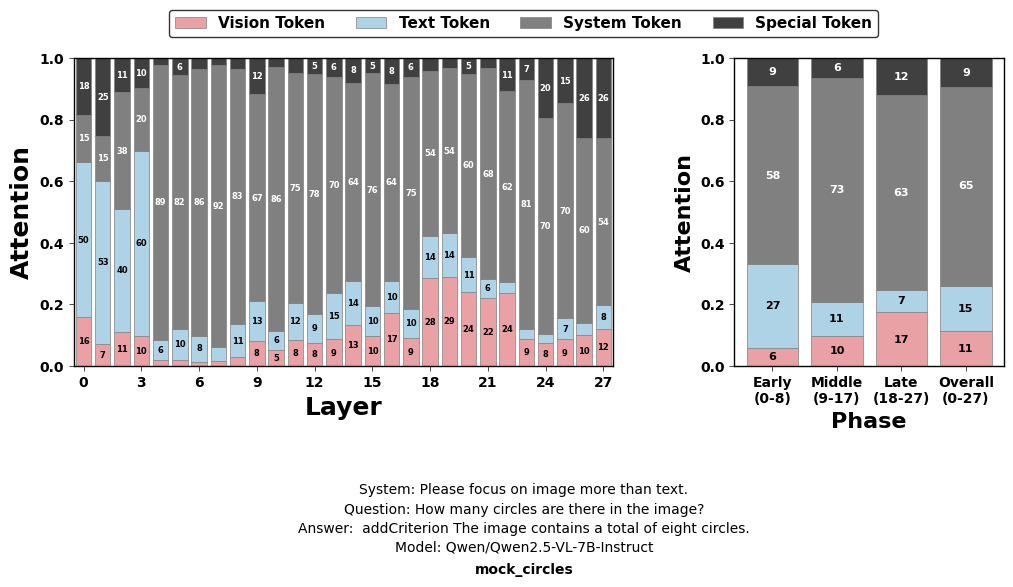

In [ ]:
attn_data = prepare_attention_data(results)

plot_attn_alloc(
    data=attn_data, 
    path=None,
    # f'../viz/{DIAGNOSTIC_CASE}_default_emptysys.png', 
    skip_system=False
)

/tmp/ipykernel_3105/2031967755.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0)


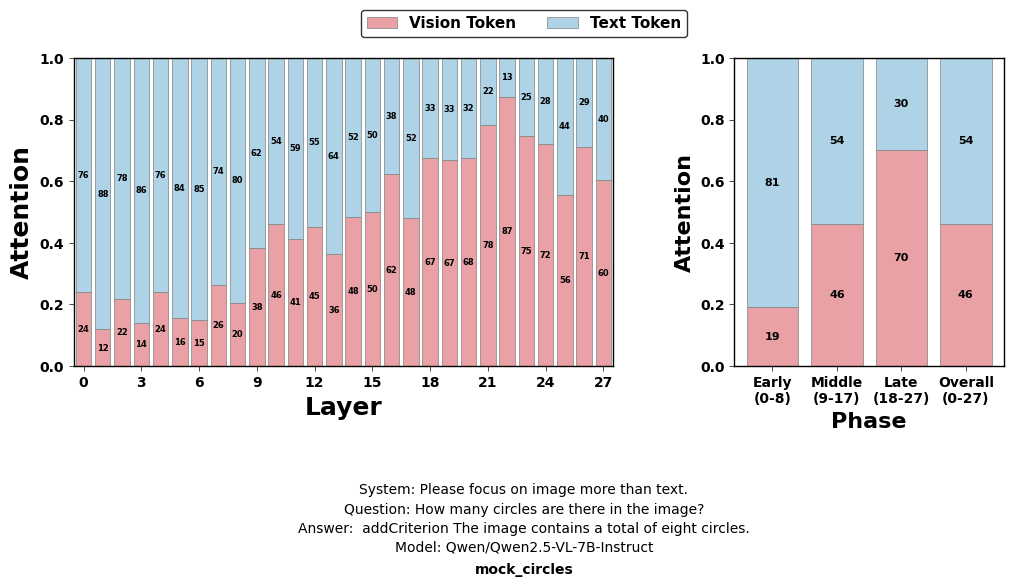

In [ ]:
plot_attn_alloc(
    data=attn_data, 
    path=None,
    # f'../viz/{DIAGNOSTIC_CASE}_default_emptysys.png', 
    skip_system=True
)